# Deliverable 2 — Gym Members Data Analysis

This notebook reproduces the analyses performed for Deliverable 2: descriptive statistics, sampling, visualizations, hypothesis tests, and regression modelling. Run cells sequentially to reproduce the saved PNGs and CSV outputs.

In [5]:
# Imports and paths
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Load your CSV (make sure it's in the same directory as the notebook)
df = pd.read_csv("cleaned_gym_members.csv")
print("Loaded", df.shape, "rows. Columns:", df.columns.tolist())

Loaded (973, 16) rows. Columns: ['age', 'gender', 'Weight (kg)', 'Height (m)', 'max_bpm', 'avg_bpm', 'Resting_BPM', 'Session_Duration (hours)', 'calories_burned', 'workout_type', 'Fat_Percentage', 'Water_Intake (liters)', 'workout_frequency', 'experience_level', 'bmi', 'age_group']


In [7]:
# Create samples
random_sample = df.sample(n=150, random_state=42).reset_index(drop=True)
systematic_sample = df.iloc[::6].reset_index(drop=True)

# Descriptive stats
random_stats = descriptive_stats(random_sample, "calories_burned")
systematic_stats = descriptive_stats(systematic_sample, "calories_burned")
population_stats = descriptive_stats(df, "calories_burned")

# Combine into one clean table
summary_table = pd.DataFrame({
    "Random Sample (n=150)": random_stats,
    "Systematic Sample (n=163)": systematic_stats,
    "Population (n=973)": population_stats
})

# Round to 3 decimals for clarity
summary_table = summary_table.round(3)

# Display neatly
summary_table

,Random Sample (n=150),Systematic Sample (n=163),Population (n=973)
count,150.000,163.000,973.000
mean,910.287,908.546,904.636
std,294.089,263.590,270.431
min,333.000,382.000,303.000
25%,709.250,739.500,720.000
50% (median),914.000,886.000,893.000
75%,1135.750,1068.000,1076.000
max,1610.000,1610.000,1610.000
skewness,0.154,0.395,0.224
kurtosis,-0.464,-0.070,-0.221


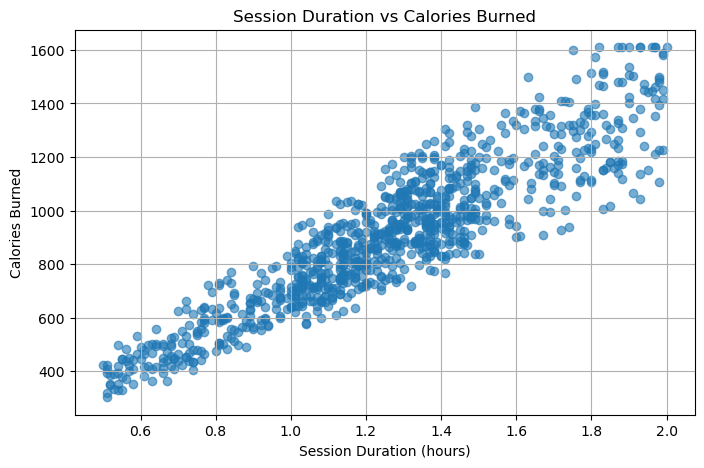

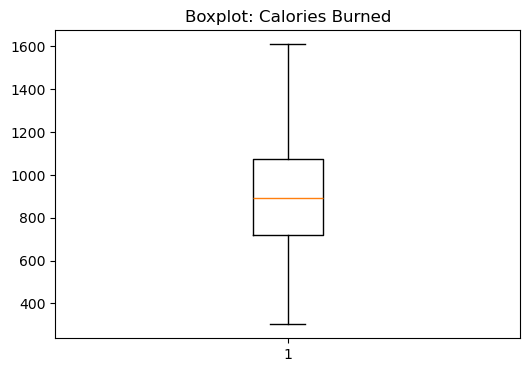

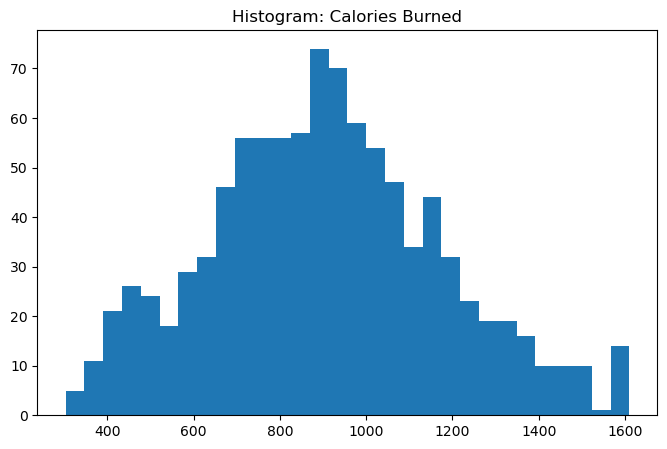

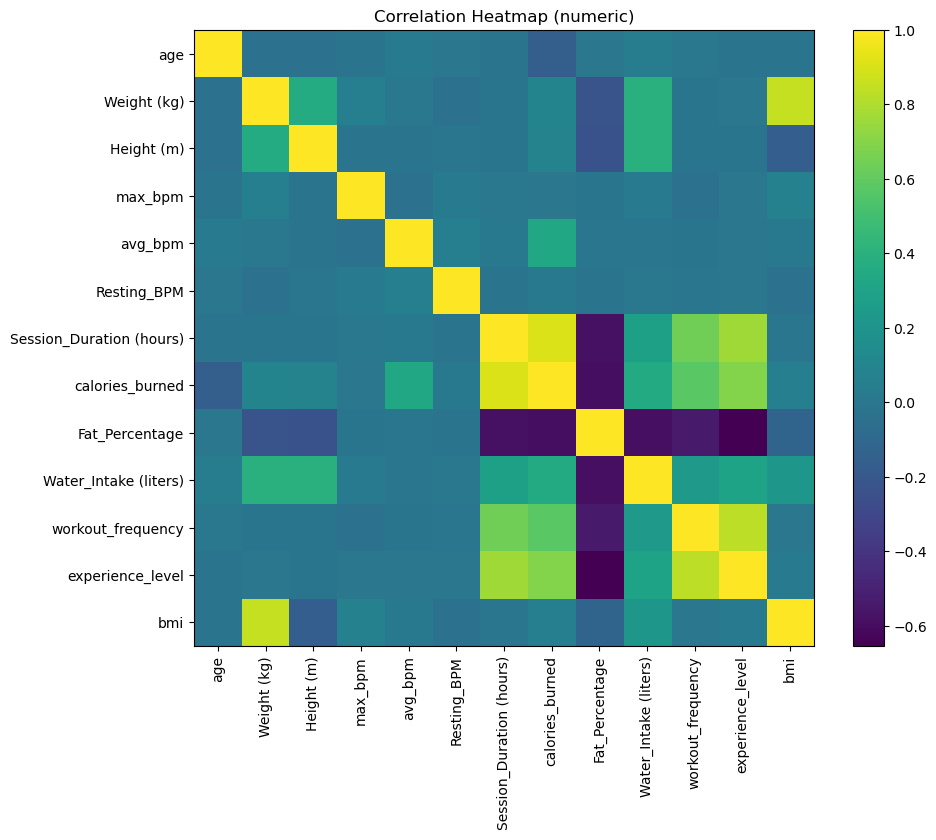

In [8]:

# Visualizations (scatter, boxplot, histogram, heatmap)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Scatter
plt.figure(figsize=(8,5))
plt.scatter(df["Session_Duration (hours)"], df["calories_burned"], alpha=0.6)
plt.title("Session Duration vs Calories Burned")
plt.xlabel("Session Duration (hours)")
plt.ylabel("Calories Burned")
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR,"scatter_duration_calories.png"), bbox_inches="tight")
plt.show()

# Boxplot
plt.figure(figsize=(6,4))
plt.boxplot(df["calories_burned"].dropna(), vert=True)
plt.title("Boxplot: Calories Burned")
plt.savefig(os.path.join(OUT_DIR,"box_calories.png"), bbox_inches="tight")
plt.show()

# Histogram
plt.figure(figsize=(8,5))
plt.hist(df["calories_burned"].dropna(), bins=30)
plt.title("Histogram: Calories Burned")
plt.savefig(os.path.join(OUT_DIR,"hist_calories.png"), bbox_inches="tight")
plt.show()

# Correlation heatmap
corr = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
plt.imshow(corr, aspect='auto', interpolation='none')
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Heatmap (numeric)")
plt.savefig(os.path.join(OUT_DIR,"heatmap_numeric_corr.png"), bbox_inches="tight")
plt.show()


In [9]:

# Hypothesis tests and regressions
# Pearson: session vs calories
clean_pair = df[["Session_Duration (hours)","calories_burned"]].dropna()
pearson_r, pearson_p = stats.pearsonr(clean_pair["Session_Duration (hours)"], clean_pair["calories_burned"])
print("Pearson r, p:", pearson_r, pearson_p)

# Spearman: avg_bpm vs calories
if "avg_bpm" in df.columns:
    sp_r, sp_p = stats.spearmanr(df["avg_bpm"].dropna(), df["calories_burned"].dropna())
    print("Spearman rho, p:", sp_r, sp_p)

# Chi-square: gender x workout_type
if "gender" in df.columns and "workout_type" in df.columns:
    cont = pd.crosstab(df["gender"], df["workout_type"])
    chi2, chi_p, chi_dof, chi_exp = stats.chi2_contingency(cont)
    print("Chi2, p, dof:", chi2, chi_p, chi_dof)

# One-sample t-test (random sample mean vs population mean)
pop_mean = df["calories_burned"].mean()
t_stat, t_p = stats.ttest_1samp(random_sample["calories_burned"].dropna(), pop_mean)
print("One-sample t-test t, p:", t_stat, t_p)

# Simple regression: session -> calories
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
X = clean_pair[["Session_Duration (hours)"]].values.reshape(-1,1)
y = clean_pair["calories_burned"].values
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Simple regression coef, intercept:", lr.coef_[0], lr.intercept_)
print("RMSE, R2:", (mean_squared_error(y_test, y_pred)**0.5), r2_score(y_test, y_pred))

# Multiple regression with available predictors
predictors = ["Weight (kg)","avg_bpm","max_bpm","Session_Duration (hours)","Fat_Percentage"]
available = [p for p in predictors if p in df.columns]
mult_df = df[available + ["calories_burned"]].dropna()
X_multi = mult_df[available].values
y_multi = mult_df["calories_burned"].values
X_tr, X_te, y_tr, y_te = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)
mlr = LinearRegression().fit(X_tr, y_tr)
y_pred_m = mlr.predict(X_te)
print("Multiple regression RMSE, R2:", (mean_squared_error(y_te, y_pred_m)**0.5), r2_score(y_te, y_pred_m))
coeffs = dict(zip(available, mlr.coef_))
print("Coefficients:", coeffs)
# Save metrics
pd.Series({"simple_rmse": (mean_squared_error(y_test, y_pred)**0.5),
           "simple_r2": r2_score(y_test, y_pred),
           "multi_rmse": (mean_squared_error(y_te, y_pred_m)**0.5),
           "multi_r2": r2_score(y_te, y_pred_m)}).to_csv(os.path.join(OUT_DIR,"regression_metrics.csv"))


Pearson r, p: 0.9098719797884693 0.0
Spearman rho, p: 0.3372804844143212 2.5908506644160673e-27
Chi2, p, dof: 1.4012902282957471 0.705232322383724 3
One-sample t-test t, p: 0.235316864030648 0.8142859139709792
Simple regression coef, intercept: 719.9359164690827 -0.9318535468312348
RMSE, R2: 121.35076861175193 0.8204275717458304
Multiple regression RMSE, R2: 66.59896937764626 0.9459134089728362
Coefficients: {'Weight (kg)': np.float64(1.1228938578711587), 'avg_bpm': np.float64(5.898058272377665), 'max_bpm': np.float64(-0.0072332019979559885), 'Session_Duration (hours)': np.float64(677.8319489239525), 'Fat_Percentage': np.float64(-3.3346776008580252)}
